# 03. Comprehensive experiment analysis

여러 training seed의 Baseline, Shared-Detach, Shared-E2E 결과를 통합 분석합니다. 학습은 수행하지 않으며, 상세 COCO 평가는 checkpoint별 inference 결과를 캐시합니다.

저장 파일은 `comprehensive_summary.csv`, `comprehensive_metrics.csv`, `comprehensive_analysis.png` 세 개로 제한합니다.

In [1]:
from pathlib import Path
import gc, importlib, sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from tqdm.auto import tqdm

ROOT = Path.cwd()
if not (ROOT / 'data').exists() and (Path('D:/gt-super') / 'data').exists(): ROOT = Path('D:/gt-super')
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))

import gt_aux.config as config_module
import gt_aux.data as data_module
import gt_aux.eval as eval_module
config_module = importlib.reload(config_module)
data_module = importlib.reload(data_module)
eval_module = importlib.reload(eval_module)
ExperimentConfig = config_module.ExperimentConfig
ID2LABEL = config_module.ID2LABEL
prepare_data, make_loaders = data_module.prepare_data, data_module.make_loaders
load_checkpoint = eval_module.load_checkpoint

d:\gt-super\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 분석 설정

학습이 완료된 seed만 `SEEDS`에 적습니다. 학습 당시 데이터·해상도 설정과 동일해야 합니다.

In [2]:
RUN_MODE = 'smoke'
SEEDS = [42, 43, 44]
DATA_SEED = 42
EXPERIMENTS = ['baseline', 'shared_detach', 'shared_e2e', 'separate_e2e']
TRAIN_IMAGES, VAL_IMAGES, EPOCHS = 400, 100, 7
BATCH_SIZE, IMAGE_MIN_SIZE, IMAGE_MAX_SIZE = 2, 384, 640
FEATURE_LEVEL = 0
RUN_DETAILED_EVALUATION = True  # False면 기존 comprehensive_metrics.csv만 사용
IOU_THRESHOLDS = [round(0.50 + 0.05 * i, 2) for i in range(10)]

CONFIG = ExperimentConfig.for_run(
    ROOT, run_mode=RUN_MODE, seed=SEEDS[0], data_seed=DATA_SEED, experiments=EXPERIMENTS,
    train_images=TRAIN_IMAGES, val_images=VAL_IMAGES, epochs=EPOCHS, batch_size=BATCH_SIZE,
    image_min_size=IMAGE_MIN_SIZE, image_max_size=IMAGE_MAX_SIZE, feature_level=FEATURE_LEVEL,
)
SUMMARY_PATH = CONFIG.output_dir / 'comprehensive_summary.csv'
METRICS_PATH = CONFIG.output_dir / 'comprehensive_metrics.csv'
FIGURE_PATH = CONFIG.output_dir / 'comprehensive_analysis.png'
CONFIG.as_dict()

{'root': 'D:\\gt-super',
 'run_mode': 'smoke',
 'checkpoint': 'SenseTime/deformable-detr',
 'train_images': 400,
 'val_images': 100,
 'epochs': 7,
 'batch_size': 2,
 'num_workers': 0,
 'image_size': {'shortest_edge': 384, 'longest_edge': 640},
 'lr': 0.0002,
 'backbone_lr': 2e-05,
 'weight_decay': 0.0001,
 'grad_clip': 0.1,
 'base_aux_weight': 0.5,
 'feature_level': 0,
 'horizontal_flip_p': 0.5,
 'use_amp': True,
 'deterministic': True,
 'save_epoch_checkpoints': False,
 'device': 'cuda',
 'experiments': ['baseline', 'shared_detach', 'shared_e2e', 'separate_e2e'],
 'seed': 42,
 'data_seed': 42}

## 1. Run 무결성 및 학습 기록 로드

In [3]:
history_frames, gradient_frames, integrity_rows = [], [], []
for seed in SEEDS:
    for experiment in EXPERIMENTS:
        history_path = CONFIG.history_path(experiment, seed)
        gradient_path = CONFIG.gradients_path(experiment, seed)
        checkpoint_path = CONFIG.checkpoint_path(experiment, seed)
        history = pd.read_csv(history_path) if history_path.exists() else pd.DataFrame()
        if not history.empty:
            history_frames.append(history)
        gradient = pd.DataFrame()
        if gradient_path.exists() and gradient_path.stat().st_size > 0:
            try: gradient = pd.read_csv(gradient_path)
            except pd.errors.EmptyDataError: pass
        if not gradient.empty: gradient_frames.append(gradient)
        observed_data_seed = history['data_seed'].dropna().unique().tolist() if 'data_seed' in history else []
        final_epoch = int(history['epoch'].max()) if not history.empty else None
        integrity_rows.append({
            'experiment': experiment, 'seed': seed, 'history': history_path.exists(),
            'checkpoint': checkpoint_path.exists(), 'final_epoch': final_epoch,
            'complete': final_epoch == EPOCHS, 'data_seed': observed_data_seed[0] if len(observed_data_seed) == 1 else None,
        })

integrity_df = pd.DataFrame(integrity_rows)
display(integrity_df)
if not history_frames: raise FileNotFoundError('분석할 history CSV가 없습니다.')
history_df = pd.concat(history_frames, ignore_index=True)
gradients_df = pd.concat(gradient_frames, ignore_index=True) if gradient_frames else pd.DataFrame()
if 'data_seed' not in history_df or sorted(history_df['data_seed'].dropna().unique()) != [DATA_SEED]:
    raise ValueError('모든 run은 수정된 코드와 동일한 DATA_SEED로 다시 학습되어야 합니다.')
complete_runs = integrity_df.query('complete and checkpoint')[['experiment', 'seed']]

,experiment,seed,history,checkpoint,final_epoch,complete,data_seed
0,baseline,42,False,True,NaN,False,NaN
1,shared_detach,42,False,True,NaN,False,NaN
2,shared_e2e,42,False,True,NaN,False,NaN
3,separate_e2e,42,True,True,7.0,True,42.0
4,baseline,43,True,True,7.0,True,42.0
5,shared_detach,43,True,True,7.0,True,42.0
6,shared_e2e,43,True,True,7.0,True,42.0
7,separate_e2e,43,True,True,7.0,True,42.0
8,baseline,44,True,True,7.0,True,42.0
9,shared_detach,44,True,True,7.0,True,42.0


## 2. 최종 성능 평균·표준편차

In [4]:
final_df = history_df.sort_values('epoch').groupby(['experiment', 'seed'], as_index=False).tail(1).copy()
final_df['localization_ratio'] = final_df['map75'] / final_df['map50'].replace(0, np.nan)
final_df['localization_gap'] = final_df['map50'] - final_df['map75']
metrics = ['map', 'map50', 'map75', 'mar100', 'localization_ratio', 'main_loss', 'train_seconds']
summary_df = final_df.groupby('experiment')[metrics].agg(['mean', 'std', 'count'])
baseline_means = summary_df.loc['baseline'].xs('mean', level=1)
flat_summary = summary_df.copy()
flat_summary.columns = [f'{metric}_{stat}' for metric, stat in flat_summary.columns]
for metric in ['map', 'map50', 'map75', 'mar100']:
    flat_summary[f'{metric}_delta_vs_baseline'] = flat_summary[f'{metric}_mean'] - baseline_means[metric]
flat_summary.to_csv(SUMMARY_PATH)
display(flat_summary)
print('Saved:', SUMMARY_PATH)

,map_mean,map_std,map_count,map50_mean,map50_std,map50_count,map75_mean,map75_std,map75_count,mar100_mean,...,main_loss_mean,main_loss_std,main_loss_count,train_seconds_mean,train_seconds_std,train_seconds_count,map_delta_vs_baseline,map50_delta_vs_baseline,map75_delta_vs_baseline,mar100_delta_vs_baseline
experiment,,,,,,,,,,,,,,,,,,,,,
baseline,0.073331,0.042367,2,0.121769,0.056961,2,0.078109,0.044485,2,0.386220,...,1.486042,0.039659,2,379.928615,1.606438,2,0.000000,0.000000,0.000000,0.000000
separate_e2e,0.078479,0.007391,3,0.127680,0.011895,3,0.087140,0.007738,3,0.431719,...,1.379707,0.034633,3,904.645118,877.967923,3,0.005148,0.005911,0.009031,0.045499
shared_detach,0.073864,0.006093,2,0.121986,0.004461,2,0.076480,0.013134,2,0.402985,...,1.443350,0.000877,2,1790.135749,105.463864,2,0.000533,0.000217,-0.001629,0.016766
shared_e2e,0.085399,0.031003,2,0.137553,0.046661,2,0.084579,0.029718,2,0.408283,...,1.352511,0.042371,2,382.065449,0.309092,2,0.012068,0.015784,0.006470,0.022064


Saved: D:\gt-super\outputs\detr_gt_auxiliary\comprehensive_summary.csv


## 3. COCO area·IoU·클래스별 상세 평가

In [5]:
BUNDLE = prepare_data(CONFIG)
_, VAL_LOADER = make_loaders(CONFIG, BUNDLE, CONFIG.seed)

@torch.inference_mode()
def collect_predictions(experiment, seed):
    model, checkpoint, _ = load_checkpoint(CONFIG, BUNDLE, experiment, seed)
    model.eval(); predictions, targets = [], []
    try:
        for batch in tqdm(VAL_LOADER, desc=f'{experiment}/seed{seed}', leave=False):
            result = model(pixel_values=batch['pixel_values'].to(CONFIG.device), pixel_mask=batch['pixel_mask'].to(CONFIG.device), labels=None)
            sizes = torch.stack([target['orig_size'] for target in batch['eval_targets']]).to(CONFIG.device)
            batch_predictions = BUNDLE.processor.post_process_object_detection(result['outputs'], threshold=0.0, target_sizes=sizes)
            predictions.extend([{k: v.detach().cpu() for k, v in item.items()} for item in batch_predictions])
            targets.extend([{'boxes': target['boxes'].cpu(), 'labels': target['labels'].cpu()} for target in batch['eval_targets']])
    finally:
        model.close(); model.cpu(); del model; gc.collect()
        if torch.cuda.is_available(): torch.cuda.empty_cache()
    return predictions, targets

def valid_scalar(value):
    value = float(value)
    return np.nan if value < 0 else value

def detailed_metrics(experiment, seed, predictions, targets):
    rows = []
    metric = MeanAveragePrecision(box_format='xyxy', iou_type='bbox', class_metrics=True)
    metric.update(predictions, targets); result = metric.compute()
    for key, source in [('all','map'), ('small','map_small'), ('medium','map_medium'), ('large','map_large')]:
        rows.append({'experiment':experiment, 'seed':seed, 'metric_type':'area', 'key':key, 'value':valid_scalar(result[source])})
    for class_id, value in zip(result['classes'].tolist(), result['map_per_class'].tolist()):
        rows.append({'experiment':experiment, 'seed':seed, 'metric_type':'class', 'key':ID2LABEL[int(class_id)], 'value':valid_scalar(value)})
    for threshold in IOU_THRESHOLDS:
        threshold_metric = MeanAveragePrecision(box_format='xyxy', iou_type='bbox', iou_thresholds=[threshold])
        threshold_metric.update(predictions, targets)
        rows.append({'experiment':experiment, 'seed':seed, 'metric_type':'iou', 'key':f'{threshold:.2f}', 'value':valid_scalar(threshold_metric.compute()['map'])})
    return rows

cached_df = pd.read_csv(METRICS_PATH) if METRICS_PATH.exists() else pd.DataFrame()
if not cached_df.empty:
    cached_df = cached_df[cached_df['experiment'].isin(EXPERIMENTS) & cached_df['seed'].isin(SEEDS)].copy()
detail_rows = cached_df.to_dict('records') if not cached_df.empty else []
expected_rows_per_run = 4 + len(IOU_THRESHOLDS) + len(ID2LABEL)
cached_pairs = set() if cached_df.empty else set(
    cached_df.groupby(['experiment','seed']).size().loc[lambda count: count >= expected_rows_per_run].index
)
if RUN_DETAILED_EVALUATION:
    for experiment, seed in complete_runs.itertuples(index=False, name=None):
        if (experiment, seed) in cached_pairs: continue
        predictions, targets = collect_predictions(experiment, seed)
        detail_rows.extend(detailed_metrics(experiment, seed, predictions, targets))
detail_df = pd.DataFrame(detail_rows)
if detail_df.empty: raise FileNotFoundError('상세 평가 cache가 없습니다. RUN_DETAILED_EVALUATION=True로 실행하세요.')
detail_df = detail_df.drop_duplicates(['experiment','seed','metric_type','key'], keep='last')
detail_df.to_csv(METRICS_PATH, index=False)
print('Saved:', METRICS_PATH)

VOC XML: 100%|██████████| 3750/3750 [00:01<00:00, 3096.87it/s]

Full split: train=3000 (9180 objects), val=750 (2530 objects)
Current run: train=400, val=100
Saved: D:\gt-super\outputs\detr_gt_auxiliary\comprehensive_metrics.csv


## 4. 통합 그래프

Saved: D:\gt-super\outputs\detr_gt_auxiliary\comprehensive_analysis.png


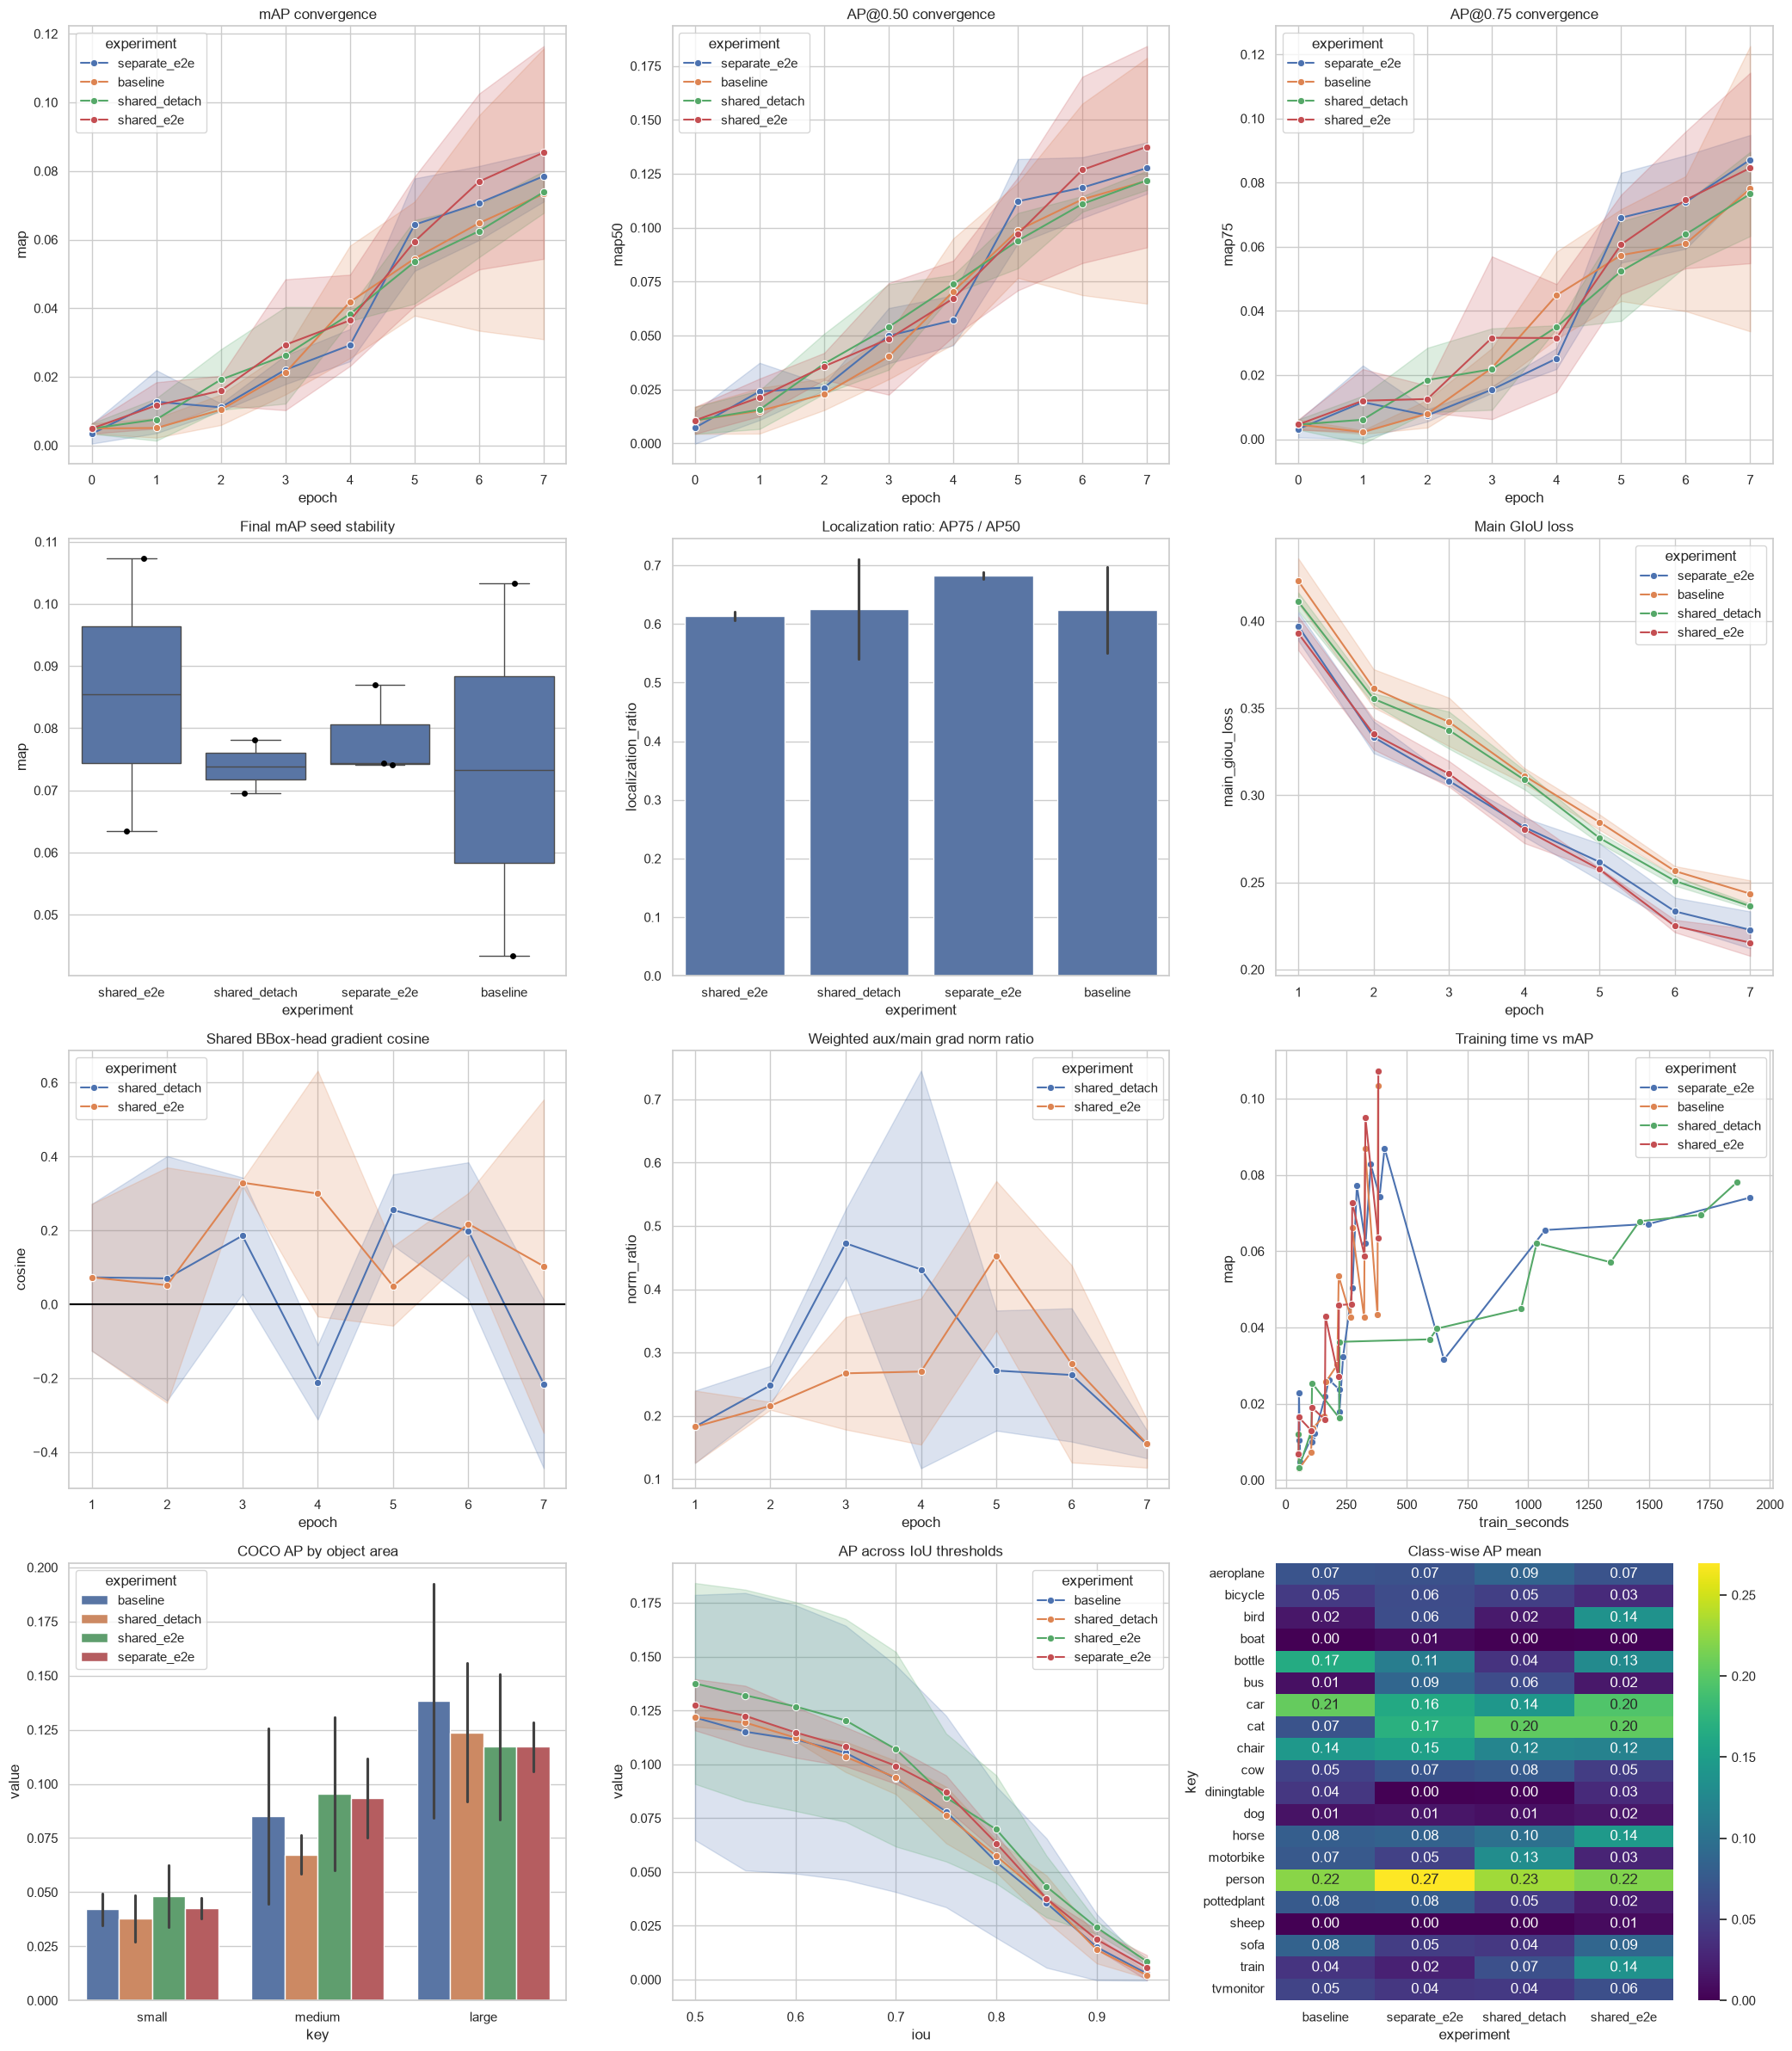

In [6]:
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(4, 3, figsize=(21, 24))
plot_specs = [('map','mAP convergence'), ('map50','AP@0.50 convergence'), ('map75','AP@0.75 convergence')]
for axis, (metric, title) in zip(axes[0], plot_specs):
    sns.lineplot(data=history_df, x='epoch', y=metric, hue='experiment', estimator='mean', errorbar='sd' if len(SEEDS)>1 else None, marker='o', ax=axis)
    axis.set_title(title)
sns.boxplot(data=final_df, x='experiment', y='map', ax=axes[1,0]); sns.stripplot(data=final_df, x='experiment', y='map', color='black', ax=axes[1,0]); axes[1,0].set_title('Final mAP seed stability')
sns.barplot(data=final_df, x='experiment', y='localization_ratio', errorbar='sd' if len(SEEDS)>1 else None, ax=axes[1,1]); axes[1,1].set_title('Localization ratio: AP75 / AP50')
sns.lineplot(data=history_df.query('epoch > 0'), x='epoch', y='main_giou_loss', hue='experiment', estimator='mean', errorbar='sd' if len(SEEDS)>1 else None, marker='o', ax=axes[1,2]); axes[1,2].set_title('Main GIoU loss')
if not gradients_df.empty:
    sns.lineplot(data=gradients_df, x='epoch', y='cosine', hue='experiment', estimator='mean', errorbar='sd' if len(SEEDS)>1 else None, marker='o', ax=axes[2,0]); axes[2,0].axhline(0,color='black'); axes[2,0].set_title('Shared BBox-head gradient cosine')
    sns.lineplot(data=gradients_df, x='epoch', y='norm_ratio', hue='experiment', estimator='mean', errorbar='sd' if len(SEEDS)>1 else None, marker='o', ax=axes[2,1]); axes[2,1].set_title('Weighted aux/main grad norm ratio')
time_df = history_df.query('epoch > 0')
sns.lineplot(data=time_df, x='train_seconds', y='map', hue='experiment', estimator='mean', marker='o', ax=axes[2,2]); axes[2,2].set_title('Training time vs mAP')
area_df = detail_df.query("metric_type == 'area' and key != 'all'")
sns.barplot(data=area_df, x='key', y='value', hue='experiment', errorbar='sd' if len(SEEDS)>1 else None, ax=axes[3,0]); axes[3,0].set_title('COCO AP by object area')
iou_df = detail_df.query("metric_type == 'iou'").copy(); iou_df['iou'] = iou_df['key'].astype(float)
sns.lineplot(data=iou_df, x='iou', y='value', hue='experiment', estimator='mean', errorbar='sd' if len(SEEDS)>1 else None, marker='o', ax=axes[3,1]); axes[3,1].set_title('AP across IoU thresholds')
class_df = detail_df.query("metric_type == 'class'").groupby(['key','experiment'])['value'].mean().unstack()
sns.heatmap(class_df, annot=True, fmt='.2f', cmap='viridis', ax=axes[3,2]); axes[3,2].set_title('Class-wise AP mean')
plt.tight_layout(); fig.savefig(FIGURE_PATH, dpi=180, bbox_inches='tight'); print('Saved:', FIGURE_PATH); plt.show()

## 5. 자동 인사이트

In [7]:
best_map = flat_summary['map_mean'].idxmax()
most_stable = flat_summary['map_std'].fillna(np.inf).idxmin()
area_means = detail_df.query("metric_type == 'area' and key != 'all'").groupby(['key','experiment'])['value'].mean()
print('• Highest mean mAP: {} ({:.4f})'.format(best_map, flat_summary.loc[best_map, 'map_mean']))
if len(SEEDS) > 1: print('• Lowest mAP seed variance: {} (SD={:.4f})'.format(most_stable, flat_summary.loc[most_stable, 'map_std']))
for area in ['small','medium','large']:
    if area in area_means.index.get_level_values(0):
        values = area_means.loc[area]; print(f'• Best AP_{area}: {values.idxmax()} ({values.max():.4f})')
best_localization = flat_summary['localization_ratio_mean'].idxmax()
print('• Best AP75/AP50 localization ratio: {} ({:.3f})'.format(best_localization, flat_summary.loc[best_localization, 'localization_ratio_mean']))
if not gradients_df.empty:
    conflict = gradients_df.groupby(['experiment','epoch'])['cosine'].mean().idxmin()
    print(f'• Strongest mean gradient conflict: {conflict[0]} epoch {conflict[1]}')
    map_change = history_df.sort_values('epoch').copy()
    map_change['map_delta'] = map_change.groupby(['experiment','seed'])['map'].diff()
    gradient_effect = gradients_df.merge(map_change[['experiment','seed','epoch','map_delta']], on=['experiment','seed','epoch'])
    if len(gradient_effect.dropna(subset=['cosine','map_delta'])) > 1:
        correlation = gradient_effect['cosine'].corr(gradient_effect['map_delta'])
        print(f'• Gradient cosine vs same-epoch ΔmAP correlation: {correlation:.3f}')
print('• Gradient cosine above is measured on the shared BBox head, not directly on the encoder.')

• Highest mean mAP: shared_e2e (0.0854)
• Lowest mAP seed variance: shared_detach (SD=0.0061)
• Best AP_small: shared_e2e (0.0483)
• Best AP_medium: shared_e2e (0.0954)
• Best AP_large: baseline (0.1383)
• Best AP75/AP50 localization ratio: separate_e2e (0.683)
• Strongest mean gradient conflict: shared_detach epoch 7
• Gradient cosine vs same-epoch ΔmAP correlation: -0.023
• Gradient cosine above is measured on the shared BBox head, not directly on the encoder.
